In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
#!/bin/bash
!kaggle datasets download sovitrath/voc-2012-segmentation-data

Dataset URL: https://www.kaggle.com/datasets/sovitrath/voc-2012-segmentation-data
License(s): CC0-1.0
 65% 207M/316M [00:00<00:00, 2.16GB/s]
100% 316M/316M [00:00<00:00, 2.17GB/s]


In [9]:
!unzip voc-2012-segmentation-data.zip -d voc-2012-data

Streaming output truncated to the last 5000 lines.
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003075.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003087.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003088.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003090.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003142.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003146.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003147.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003164.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003172.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003200.jpg  
  inflating: voc-2012-data/voc_2012_segmentation_data/train_images/2009_003249.jpg  
  inflating: v

In [10]:
import os
import cv2
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout

In [11]:
image_path = '/content/voc-2012-data/voc_2012_segmentation_data/train_images'
mask_path = '/content/voc-2012-data/voc_2012_segmentation_data/train_labels'

In [12]:
images = os.listdir(image_path)
masks = os.listdir(mask_path)

In [13]:
len(images)

1464

In [14]:
len(masks)

1464

In [15]:
def random_image_show(num):
    plt.figure(figsize=(10, 10))
    for i in range(num):
        image_list = random.choice(images)
        img = Image.open(f'/content/voc-2012-data/voc_2012_segmentation_data/train_images/{image_list}')
        temp = image_list.split('.')[0]
        mask = Image.open(f'/content/voc-2012-data/voc_2012_segmentation_data/train_labels/{temp}.png')

        plt.subplot(2, num, i + 1)
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(2, num, num + i + 1)
        plt.imshow(mask)
        plt.title("Mask Image")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


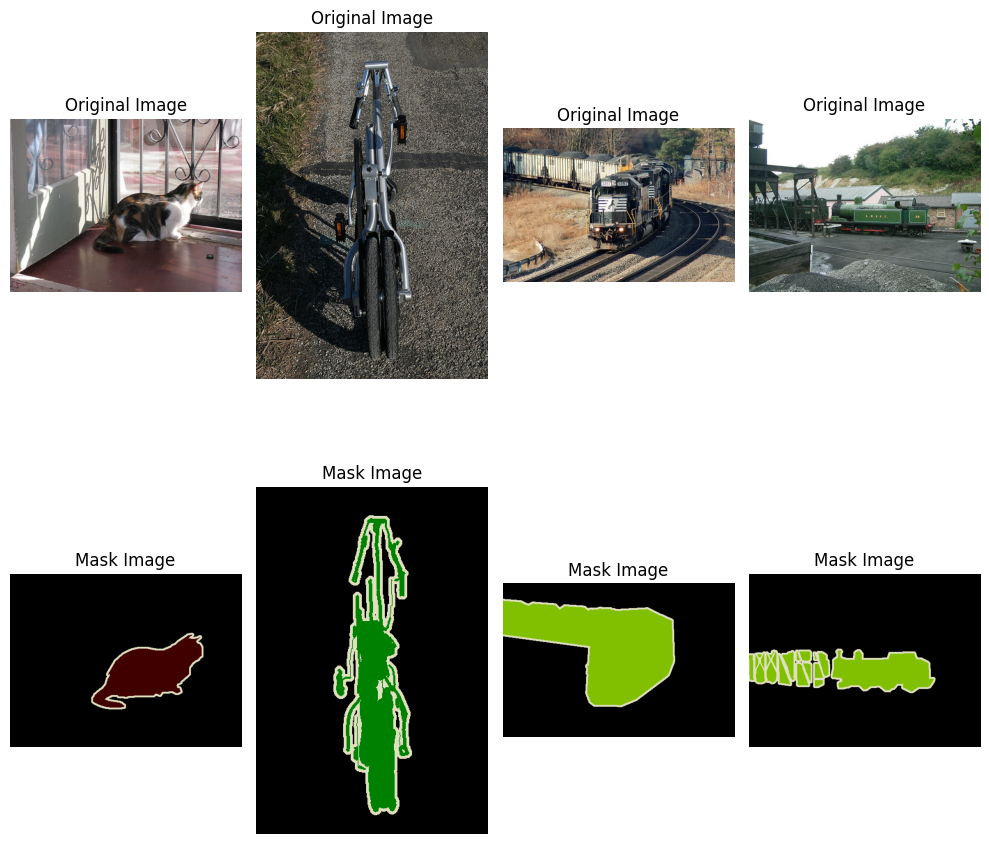

In [16]:
random_image_show(4)

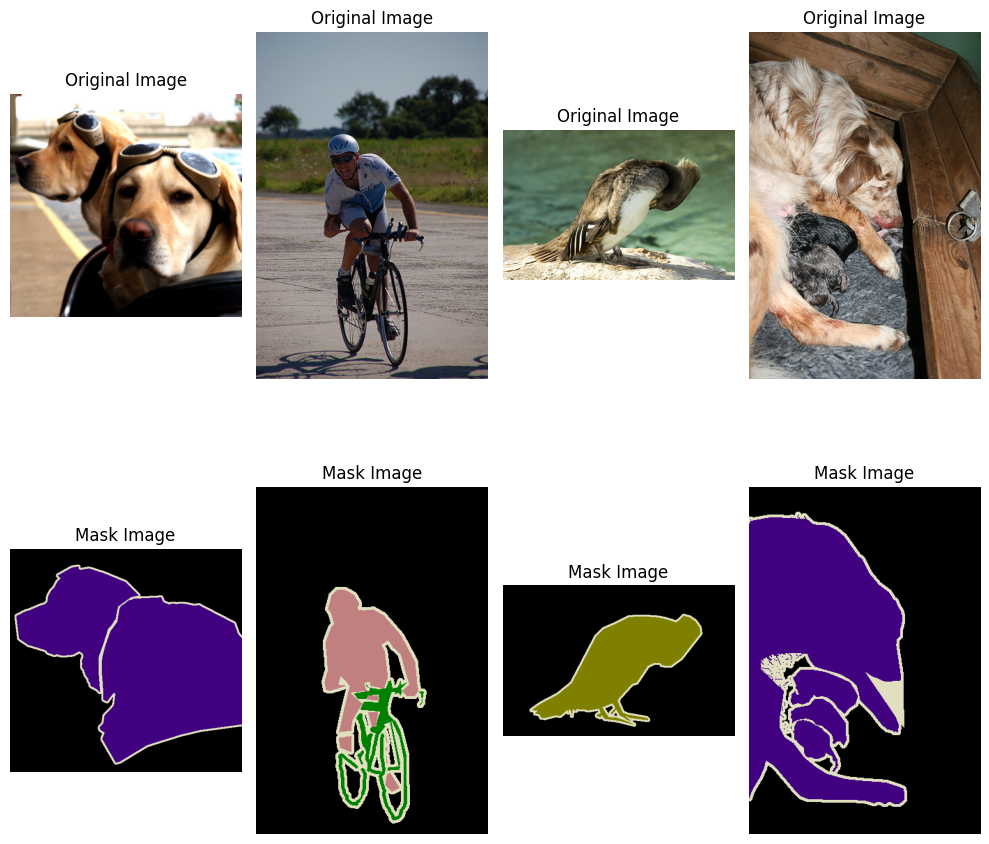

In [17]:
random_image_show(4)

# Loading the data

In [18]:
def load_data(image_dir, mask_dir, img_size=(224, 224)):
    images = []
    masks = []

    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        # Assuming mask file has the same name but with .png extension
        mask_file_name = img_file.split('.')[0] + '.png'
        mask_path = os.path.join(mask_dir, mask_file_name)

        if os.path.exists(mask_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
            img = cv2.resize(img, img_size)
            images.append(img)

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) # Read mask as grayscale
            mask = cv2.resize(mask, img_size)
            masks.append(mask)

    return np.array(images), np.array(masks)

# Call the function with the defined paths and print shapes
images_array, masks_array = load_data(image_path, mask_path)

print(f"Shape of images_array: {images_array.shape}")
print(f"Shape of masks_array: {masks_array.shape}")

Shape of images_array: (1464, 224, 224, 3)
Shape of masks_array: (1464, 224, 224)


In [19]:
image_dir = '/content/voc-2012-data/voc_2012_segmentation_data/train_images'
mask_dir = '/content/voc-2012-data/voc_2012_segmentation_data/train_labels'
X, masks = load_data(image_dir,mask_dir)

In [41]:
X_data, y_data = load_data(image_dir, mask_dir, img_size=(256, 256))
X_test, y_test = load_data('/content/voc-2012-data/voc_2012_segmentation_data/valid_images','/content/voc-2012-data/voc_2012_segmentation_data/valid_labels', img_size=(256, 256))

# Normalize images and masks to [0, 1] range and cast to float32
X_data = X_data / 255.0
y_data = y_data / 255.0
X_test = X_test / 255.0
y_test = y_test / 255.0

X_data = X_data.astype(np.float32)
y_data = y_data.astype(np.float32)
X_test = X_test.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Reshape y_train, y_val, and y_test to add a channel dimension
y_train = np.expand_dims(y_train, axis=-1)
y_val = np.expand_dims(y_val, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

## Building Convolution Block

In [21]:
# Function to create a convolutional block for the U-Net model
def convolutional_block(input_tensor, num_filters, kernel_size=3, use_batch_norm=True):
    """
    Performs two convolution operations with optional batch normalization.

    Args:
        input_tensor (tensor): Input to the convolutional block.
        num_filters (int): Number of filters for the convolutional layers.
        kernel_size (int, optional): Size of the convolution kernel. Defaults to 3.
        use_batch_norm (bool, optional): Apply batch normalization if True. Defaults to True.

    Returns:
        tensor: Output after applying convolution, batch normalization, and activation.
    """
    # First convolution
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=(kernel_size, kernel_size),
                               kernel_initializer='he_normal', padding='same')(input_tensor)
    if use_batch_norm:
        x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Second convolution
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=(kernel_size, kernel_size),
                               kernel_initializer='he_normal', padding='same')(x)
    if use_batch_norm:
        x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

## Building UNET Model

In [22]:
# Function to create a U-Net model
def build_unet(input_shape, num_filters=16, dropout_rate=0.1, use_batch_norm=True):
    """
    Builds a U-Net model.

    Args:
        input_shape (tuple): Shape of the input image (height, width, channels).
        num_filters (int, optional): Number of filters for the initial layer. Defaults to 16.
        dropout_rate (float, optional): Dropout rate for regularization. Defaults to 0.1.
        use_batch_norm (bool, optional): Apply batch normalization if True. Defaults to True.

    Returns:
        keras.Model: Compiled U-Net model.
    """
    inputs = tf.keras.layers.Input(input_shape)

    # Encoder path
    c1 = convolutional_block(inputs, num_filters * 1, use_batch_norm=use_batch_norm)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    p1 = tf.keras.layers.Dropout(dropout_rate)(p1)

    c2 = convolutional_block(p1, num_filters * 2, use_batch_norm=use_batch_norm)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    p2 = tf.keras.layers.Dropout(dropout_rate)(p2)

    c3 = convolutional_block(p2, num_filters * 4, use_batch_norm=use_batch_norm)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    p3 = tf.keras.layers.Dropout(dropout_rate)(p3)

    c4 = convolutional_block(p3, num_filters * 8, use_batch_norm=use_batch_norm)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    p4 = tf.keras.layers.Dropout(dropout_rate)(p4)

    # Bottleneck
    c5 = convolutional_block(p4, num_filters * 16, use_batch_norm=use_batch_norm)

    # Decoder path
    u6 = tf.keras.layers.Conv2DTranspose(num_filters * 8, (3, 3), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    u6 = tf.keras.layers.Dropout(dropout_rate)(u6)
    c6 = convolutional_block(u6, num_filters * 8, use_batch_norm=use_batch_norm)

    u7 = tf.keras.layers.Conv2DTranspose(num_filters * 4, (3, 3), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    u7 = tf.keras.layers.Dropout(dropout_rate)(u7)
    c7 = convolutional_block(u7, num_filters * 4, use_batch_norm=use_batch_norm)

    u8 = tf.keras.layers.Conv2DTranspose(num_filters * 2, (3, 3), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    u8 = tf.keras.layers.Dropout(dropout_rate)(u8)
    c8 = convolutional_block(u8, num_filters * 2, use_batch_norm=use_batch_norm)

    u9 = tf.keras.layers.Conv2DTranspose(num_filters * 1, (3, 3), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    u9 = tf.keras.layers.Dropout(dropout_rate)(u9)
    c9 = convolutional_block(u9, num_filters * 1, use_batch_norm=use_batch_norm)

    # Output layer
    output = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    # Model creation
    model = tf.keras.Model(inputs=[inputs], outputs=[output])
    return model


In [23]:
# Instantiate and compile the U-Net model
input_shape = (256, 256, 3)
unet_model = build_unet(input_shape, dropout_rate=0.07)
unet_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_1[

 Total params: 2,164,593 (8.26 MB)

 Trainable params: 2,161,649 (8.25 MB)

 Non-trainable params: 2,944 (11.50 KB)

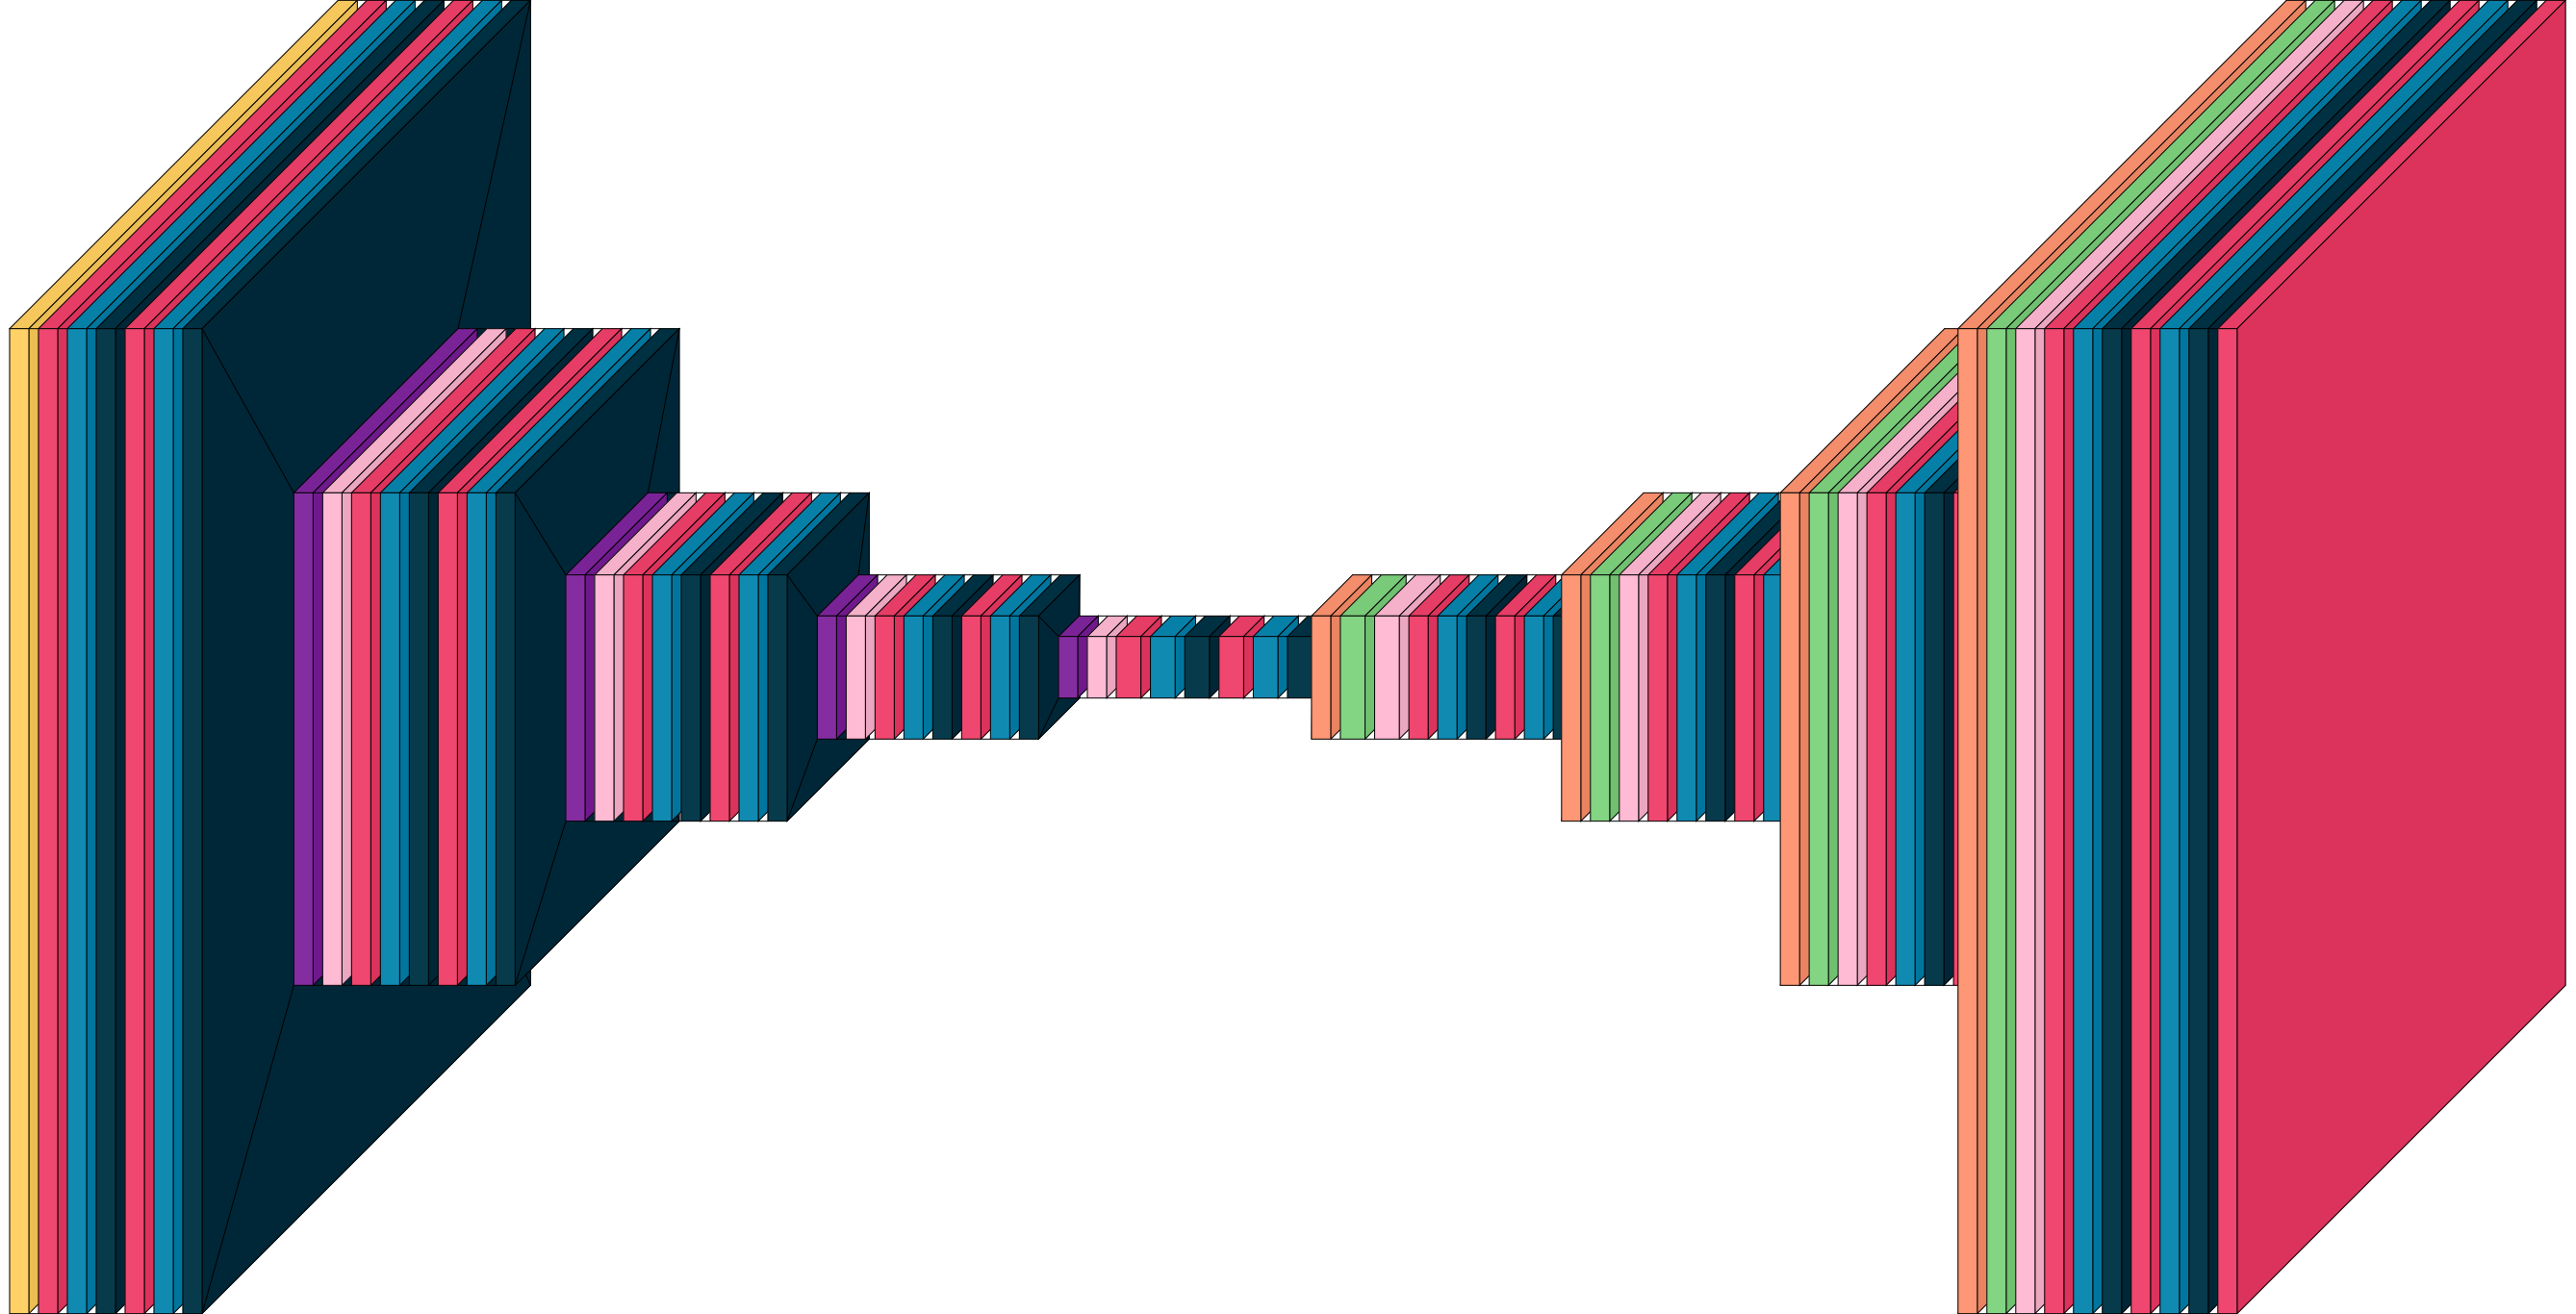

In [33]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, min_lr=1e-6)
model_checkpoint = ModelCheckpoint('unet_model_best.keras', monitor='val_loss', save_best_only=True, verbose=1)

In [45]:
# Retrain the model with run_eagerly=True
history = unet_model.fit(X_train,
                         y_train,
                         validation_data=(X_val, y_val),
                         epochs=50,
                         verbose=1,
                         callbacks=[early_stopping, reduce_lr, model_checkpoint])

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5734 - loss: 0.5731
Epoch 1: val_loss improved from inf to 459.83868, saving model to unet_model_best.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 426ms/step - accuracy: 0.5751 - loss: 0.5712 - val_accuracy: 0.0421 - val_loss: 459.8387 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.6956 - loss: 0.3959
Epoch 2: val_loss improved from 459.83868 to 0.97157, saving model to unet_model_best.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 324ms/step - accuracy: 0.6954 - loss: 0.3958 - val_accuracy: 0.3503 - val_loss: 0.9716 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6933 - loss: 0.3753
Epoch 3: val_loss improved from 0.97157 to 0.50982, saving model to unet_model_best.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 325ms/step - accuracy: 0.6932 - loss: 0.3753 - val_accuracy: 0.6718 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 301

KeyboardInterrupt: 

In [42]:
# Train the model
history = unet_model.fit(X_train,
                         y_train,
                         validation_data=(X_val, y_val),
                         epochs=50,
                         verbose=1,
                         callbacks=[early_stopping, reduce_lr, model_checkpoint])

Epoch 1/50


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

In [ ]:
# Plot training and validation loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.grid()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.grid()
plt.title('Accuracy')

plt.show()

In [ ]:
# Function to predict and time the inference for a single image
def predict_single_image(image, model):
    """
    Predicts the segmentation mask for a single image and times the prediction.

    Args:
        image (array): Input image for prediction.
        model (keras.Model): Trained U-Net model.

    Returns:
        tuple: Predicted mask and inference time.
    """
    start_time = time.time()
    prediction = model.predict(np.expand_dims(image, axis=0))[0, :, :, 0]
    end_time = time.time()
    inference_time = end_time - start_time

    return prediction, inference_time

In [ ]:
# Function to visualize the prediction and ground truth
def visualize_segmentation(image, predicted_mask, ground_truth_mask):
    """
    Visualizes the original image, predicted mask, and ground truth mask.

    Args:
        image (array): Original image.
        predicted_mask (array): Predicted mask.
        ground_truth_mask (array): Ground truth mask.
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(predicted_mask, cmap='gray')
    plt.title('Predicted Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(ground_truth_mask, cmap='gray')
    plt.title('Ground Truth Mask')

    plt.show()

In [ ]:
# Example inference on a validation image
sample_image = X_val[0]
sample_ground_truth = y_val[0]

predicted_mask, inference_time = predict_single_image(sample_image, unet_model)
print(f'Inference time for a single image: {inference_time:.4f} seconds')

# Visualize the result
visualize_segmentation(sample_image, predicted_mask, sample_ground_truth)

In [ ]:
# Example inference on a validation image
sample_image = X_val[10]
sample_ground_truth = y_val[10]

predicted_mask, inference_time = predict_single_image(sample_image, unet_model)
print(f'Inference time for a single image: {inference_time:.4f} seconds')

# Visualize the result
visualize_segmentation(sample_image, predicted_mask, sample_ground_truth)

In [43]:
unet_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'], run_eagerly=True)

In [44]:
unet_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'], run_eagerly=True)